# 05 — Topic Modeling (BERTopic)

Semantic topic discovery from paper abstracts, titles, and author keywords.

**Pipeline:** sentence embeddings → ablation study (Part A) → auto-select best config → BERTopic final pipeline (Part B)

- **Part A** — 7 configs (dim-reduction × algorithm × metric), evaluated on a shared UMAP-2D space  
- **Part B** — BERTopic with the winning config: keywords, UMAP scatter, centroid distances, coding cross-tabs, temporal network

**Requires:** `data/processed/corpus_clean.parquet` (run NB00 first)  
**Model:** `sentence-transformers/all-mpnet-base-v2`

In [38]:
# ── IMPORTS & CONFIG ──────────────────────────────────────────────────────────
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, normalized_mutual_info_score,
)
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import normalize

from sentence_transformers import SentenceTransformer
from hdbscan import HDBSCAN
from umap import UMAP
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from wordcloud import WordCloud
from pyvis.network import Network as PNetwork
from IPython.display import display, IFrame

sys.path.insert(0, "..")
from scripts.utils import load_processed, save_figure, STYLE

PROCESSED_DIR = "../data/processed/"
OUT = Path("../outputs/")
OUT.mkdir(parents=True, exist_ok=True)

GENERIC_KEYWORD_STOPLIST: set[str] = {
    # Cheating-related terms from Scopus query
    "cheat", "cheats", "cheating", "cheater", "cheaters",
    "anti-cheat", "anticheat", "ban evasion", "smurfing",

    # Gaming platform/genre terms from Scopus query
    "game", "games", "gaming", "videogame", "videogames", "esport", "esports", "e-sport", "e-sports", "mmo", "mmog", "mmorpg",
    "battle royale", "moba", "fps", "first person shooter", "first-person shooter", "first-person-shooter"
    "multiplayer", "multi-player", "multi-player game", "networked game", "computer game", 

}

CLUSTER_PALETTE = [
    "#E63946", "#2E86AB", "#F18F01", "#44BBA4", "#A23B72", "#3B1F2B",
    "#F94144", "#457B9D", "#81B29A", "#264653", "#2A9D8F", "#E9C46A",
    "#F4A261", "#E76F51", "#CDB4DB", "#BDE0FE", "#A8DADC",
    "#023047", "#FFB703", "#FB8500", "#ADB5BD", "#6D6875",
]

df = load_processed("corpus_clean")
N  = len(df)
print(f"Corpus: N={N} | Years: {df.Year.min()}–{df.Year.max()}")
print(f"Abstract present: {df['Abstract'].notna().sum()} / {N}")

Corpus: N=375 | Years: 2000–2026
Abstract present: 373 / 375


## Text Preparation & Embedding

In [39]:
df["text_topic"] = (
    df["Title"].fillna("") + ". "
    + df["Abstract"].fillna("") + " "
    + df["author_keywords"].fillna("")
).str.replace(r"[;/]", " ", regex=True).str.strip()

docs    = df["text_topic"].tolist()
lengths = [len(d.split()) for d in docs]
print(f"Documents: {len(docs)}")
print(f"Mean length: {np.mean(lengths):.0f} words | min={min(lengths)} max={max(lengths)}")

print("\nLoading sentence-transformers model...")
st_model   = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
X_emb      = st_model.encode(docs, show_progress_bar=True, batch_size=32)
X_emb_norm = normalize(X_emb, norm="l2")  # for cosine-K-Means: L2-norm + euclidean ≡ cosine
print(f"Embedding shape: {X_emb.shape}")

Documents: 375
Mean length: 183 words | min=7 max=694

Loading sentence-transformers model...


Batches: 100%|██████████| 12/12 [00:12<00:00,  1.03s/it]

Embedding shape: (375, 768)


## Part A — Ablation Study

All 7 configurations are **clustered in their own high-dimensional space** and  
**evaluated on a shared UMAP-2D projection** — this guarantees metric comparability  
across configs without forcing the same geometry on the clustering step.

| Config | Input space  | Algorithm           | Metric            |
|--------|--------------|---------------------|-------------------|
| A      | raw 384D     | HDBSCAN             | cosine (L2+eucl.) |
| B      | UMAP-5D      | HDBSCAN             | euclidean         |
| C      | UMAP-5D      | K-Means (K opt.)    | euclidean         |
| D      | UMAP-5D      | K-Means (K opt.)    | cosine (L2+eucl.) |
| E      | PCA-50D      | K-Means (K opt.)    | euclidean         |
| F      | PCA-50D      | K-Means (K opt.)    | cosine (L2+eucl.) |
| G      | raw 384D     | K-Means (K opt.)    | cosine (L2+eucl.) |

In [40]:
# High-dimensional spaces for clustering
print("PCA → 50D...")
pca        = PCA(n_components=50, random_state=42)
X_pca      = pca.fit_transform(X_emb)
X_pca_norm = normalize(X_pca, norm="l2")
print(f"  Cumulative explained variance: {pca.explained_variance_ratio_.sum():.1%}")

print("UMAP → 5D (clustering space, min_dist=0 maximises cluster density)...")
umap5        = UMAP(n_components=5, n_neighbors=10, metric="cosine", min_dist=0.0, random_state=42)
X_umap5      = umap5.fit_transform(X_emb)
X_umap5_norm = normalize(X_umap5, norm="l2")

# Shared 2D projection — used ONLY for metric evaluation and scatter visualisation
print("UMAP → 2D (shared evaluation & visualisation space)...")
umap2  = UMAP(n_components=2, n_neighbors=15, metric="cosine", min_dist=0.1, random_state=42)
X_2d   = umap2.fit_transform(X_emb)
df["umap_x"] = X_2d[:, 0]
df["umap_y"] = X_2d[:, 1]
print("Reductions complete.")

PCA → 50D...
  Cumulative explained variance: 78.9%
UMAP → 5D (clustering space, min_dist=0 maximises cluster density)...
UMAP → 2D (shared evaluation & visualisation space)...
Reductions complete.


In [41]:
K_RANGE = range(2, 20)

def find_best_k(X_cluster, X_eval, k_range=K_RANGE):
    best_k, best_sil, best_labels = None, -1.0, None
    for k in k_range:
        km  = KMeans(n_clusters=k, random_state=42, n_init=10)
        lbl = km.fit_predict(X_cluster)
        sil = silhouette_score(X_eval, lbl)
        if sil > best_sil:
            best_k, best_sil, best_labels = k, sil, lbl.copy()
    return best_labels, best_k, best_sil


def eval_config(labels, X_2d):
    arr   = np.array(labels)
    mask  = arr >= 0
    n_cl  = len(set(arr[mask]))
    n_out = int((~mask).sum())
    if mask.sum() < 2 or n_cl < 2:
        return np.nan, np.nan, n_out, n_cl
    return silhouette_score(X_2d[mask], arr[mask]), davies_bouldin_score(X_2d[mask], arr[mask]), n_out, n_cl


configs = {}

print("Config A: raw-384D + HDBSCAN cosine...")
lbl_a = HDBSCAN(min_cluster_size=10, min_samples=5, metric="euclidean",
                 cluster_selection_method="eom").fit_predict(X_emb_norm)
configs["A"] = dict(labels=lbl_a, space="raw-384D", algo="HDBSCAN", metric="cosine*",
                    **(lambda s,d,o,k: dict(silhouette=s,db_score=d,outliers=o,n_clusters=k))(*eval_config(lbl_a,X_2d)))

print("Config B: UMAP-5D + HDBSCAN euclidean...")
lbl_b = HDBSCAN(min_cluster_size=10, min_samples=5, metric="euclidean",
                 cluster_selection_method="eom").fit_predict(X_umap5)
configs["B"] = dict(labels=lbl_b, space="UMAP-5D", algo="HDBSCAN", metric="euclidean",
                    **(lambda s,d,o,k: dict(silhouette=s,db_score=d,outliers=o,n_clusters=k))(*eval_config(lbl_b,X_2d)))

print("Config C: UMAP-5D + K-Means euclidean...")
lbl_c, k_c, _ = find_best_k(X_umap5, X_2d)
configs["C"] = dict(labels=lbl_c, space="UMAP-5D", algo=f"K-Means (K={k_c})", metric="euclidean",
                    **(lambda s,d,o,k: dict(silhouette=s,db_score=d,outliers=o,n_clusters=k))(*eval_config(lbl_c,X_2d)))

print("Config D: UMAP-5D + K-Means cosine...")
lbl_d, k_d, _ = find_best_k(X_umap5_norm, X_2d)
configs["D"] = dict(labels=lbl_d, space="UMAP-5D", algo=f"K-Means (K={k_d})", metric="cosine",
                    **(lambda s,d,o,k: dict(silhouette=s,db_score=d,outliers=o,n_clusters=k))(*eval_config(lbl_d,X_2d)))

print("Config E: PCA-50D + K-Means euclidean...")
lbl_e, k_e, _ = find_best_k(X_pca, X_2d)
configs["E"] = dict(labels=lbl_e, space="PCA-50D", algo=f"K-Means (K={k_e})", metric="euclidean",
                    **(lambda s,d,o,k: dict(silhouette=s,db_score=d,outliers=o,n_clusters=k))(*eval_config(lbl_e,X_2d)))

print("Config F: PCA-50D + K-Means cosine...")
lbl_f, k_f, _ = find_best_k(X_pca_norm, X_2d)
configs["F"] = dict(labels=lbl_f, space="PCA-50D", algo=f"K-Means (K={k_f})", metric="cosine",
                    **(lambda s,d,o,k: dict(silhouette=s,db_score=d,outliers=o,n_clusters=k))(*eval_config(lbl_f,X_2d)))

print("Config G: raw-384D + K-Means cosine...")
lbl_g, k_g, _ = find_best_k(X_emb_norm, X_2d)
configs["G"] = dict(labels=lbl_g, space="raw-384D", algo=f"K-Means (K={k_g})", metric="cosine",
                    **(lambda s,d,o,k: dict(silhouette=s,db_score=d,outliers=o,n_clusters=k))(*eval_config(lbl_g,X_2d)))

df_abl = pd.DataFrame([
    {"Config": k, "Space": v["space"], "Algorithm": v["algo"], "Metric": v["metric"],
     "N topics": v["n_clusters"], "Outliers": v["outliers"],
     "Silhouette ↑": round(v["silhouette"], 3) if not np.isnan(v["silhouette"]) else np.nan,
     "Davies-Bouldin ↓": round(v["db_score"], 3) if not np.isnan(v["db_score"]) else np.nan}
    for k, v in configs.items()
])
print("\n=== Ablation Results ===")
display(df_abl)

Config A: raw-384D + HDBSCAN cosine...
Config B: UMAP-5D + HDBSCAN euclidean...
Config C: UMAP-5D + K-Means euclidean...
Config D: UMAP-5D + K-Means cosine...
Config E: PCA-50D + K-Means euclidean...
Config F: PCA-50D + K-Means cosine...
Config G: raw-384D + K-Means cosine...

=== Ablation Results ===


,Config,Space,Algorithm,Metric,N topics,Outliers,Silhouette ↑,Davies-Bouldin ↓
0,A,raw-384D,HDBSCAN,cosine*,2,276,0.434,0.699
1,B,UMAP-5D,HDBSCAN,euclidean,6,9,0.538,0.594
2,C,UMAP-5D,K-Means (K=4),euclidean,4,0,0.585,0.602
3,D,UMAP-5D,K-Means (K=4),cosine,4,0,0.578,0.619
4,E,PCA-50D,K-Means (K=4),euclidean,4,0,0.532,0.645
5,F,PCA-50D,K-Means (K=3),cosine,3,0,0.512,0.660
6,G,raw-384D,K-Means (K=4),cosine,4,0,0.537,0.632


In [42]:
# Fig A.1 — Comparison table (Plotly)
valid_mask = df_abl["Silhouette ↑"].notna()
best_row   = int(df_abl.loc[valid_mask, "Silhouette ↑"].idxmax())
best_cfg   = df_abl.loc[best_row, "Config"]

cols_show = ["Config", "Space", "Algorithm", "Metric", "N topics", "Outliers",
             "Silhouette ↑", "Davies-Bouldin ↓"]

fill_colors = [
    ["#D4EDDA" if i == best_row else "white" for i in range(len(df_abl))]
    for _ in cols_show
]

fig_abl = go.Figure(go.Table(
    header=dict(
        values=[f"<b>{c}</b>" for c in cols_show],
        fill_color="#2E86AB", font=dict(color="white", size=12),
        align="center", height=32,
    ),
    cells=dict(
        values=[df_abl[c].tolist() for c in cols_show],
        fill_color=fill_colors,
        align="center", font=dict(size=11),
        height=28,
    ),
))
fig_abl.update_layout(
    title=(
        f"Fig A.1 — Ablation: dim-reduction × algorithm × metric<br>"
        f"<sup>Metrics evaluated on shared UMAP-2D space. "
        f"Green = best silhouette (Config {best_cfg}). "
        f"* cosine via L2-norm + euclidean</sup>"
    ),
    height=340,
    margin=dict(t=90),
)
fig_abl.show()
save_figure(fig_abl, "05_A1_ablation_table")
print(f"\nWinning config: {best_cfg} — {configs[best_cfg]['space']} | "
      f"{configs[best_cfg]['algo']} | silhouette={configs[best_cfg]['silhouette']:.3f}")


Winning config: C — UMAP-5D | K-Means (K=4) | silhouette=0.585


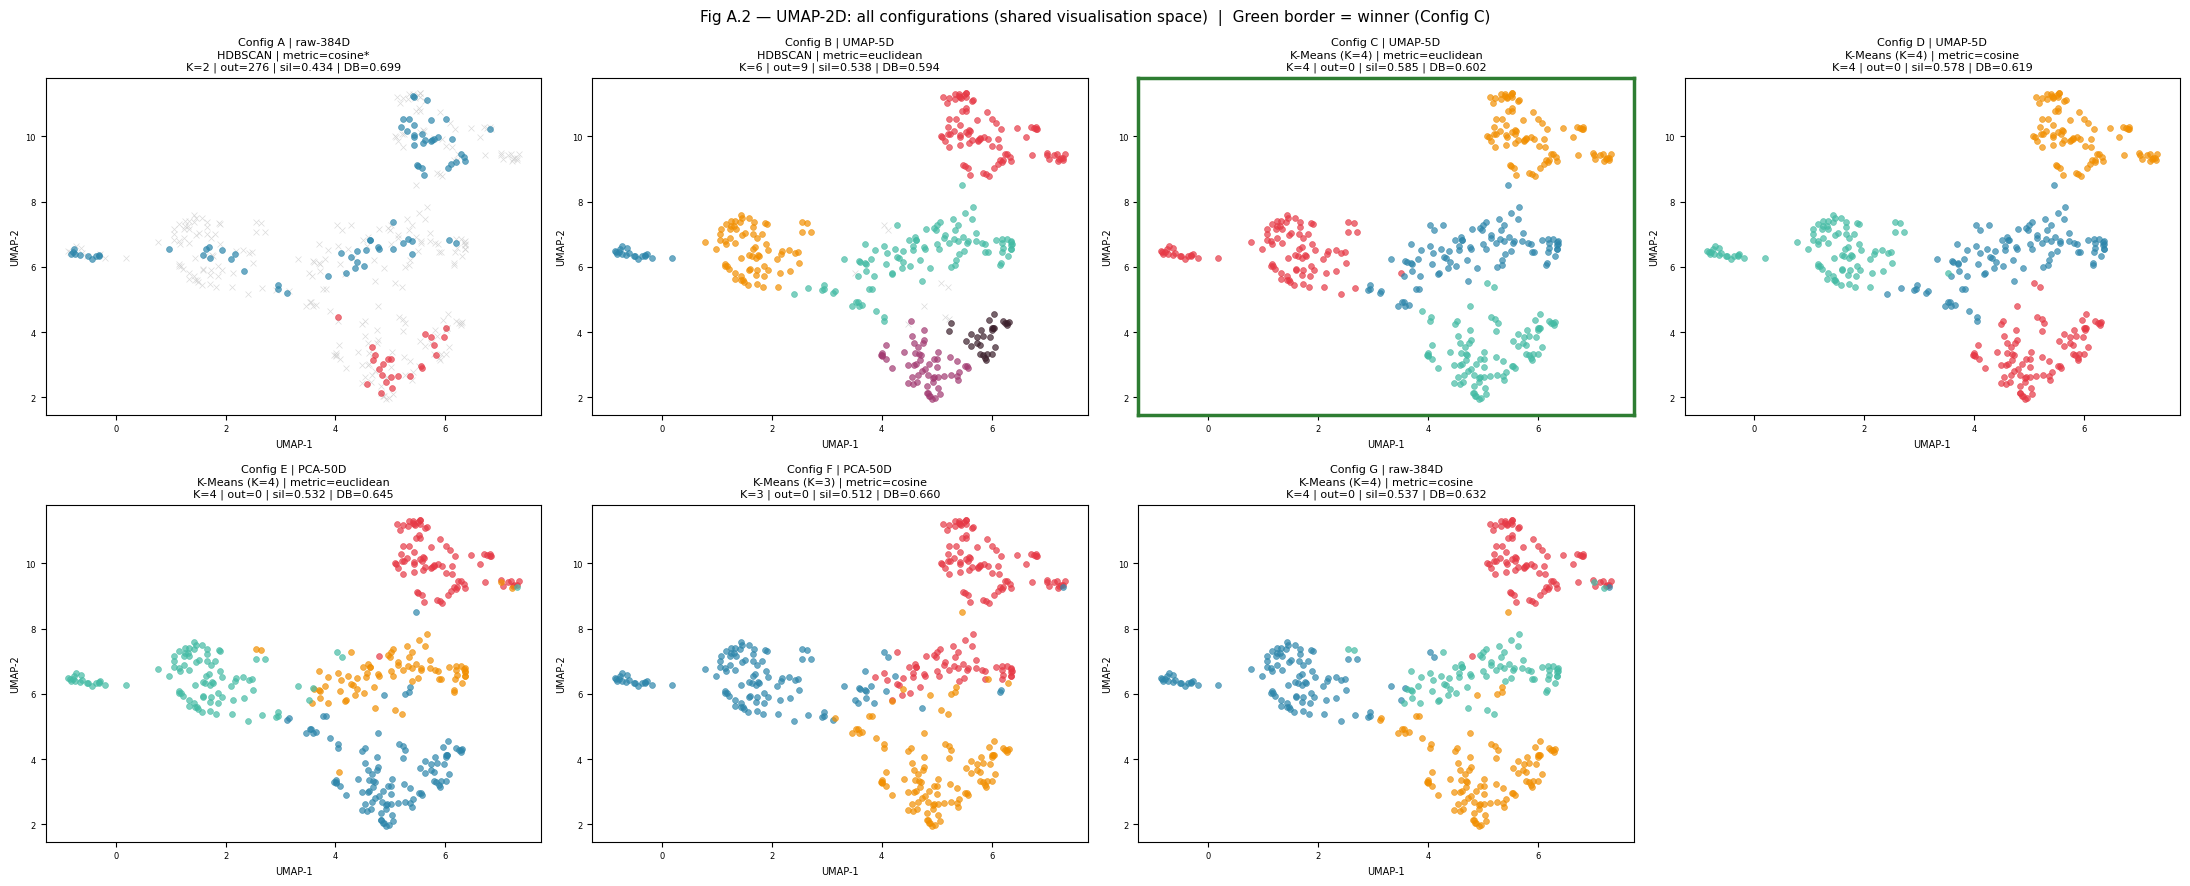

In [43]:
# Fig A.2 — UMAP-2D scatter grid for all configurations (matplotlib static PNG)
config_ids = list(configs.keys())
ncols_g, nrows_g = 4, 2

fig_grid, axes = plt.subplots(nrows_g, ncols_g, figsize=(5.5 * ncols_g, 4.5 * nrows_g))
axes = np.array(axes).flatten()

for i, cfg_id in enumerate(config_ids):
    ax  = axes[i]
    lbl = np.array(configs[cfg_id]["labels"])
    for u in sorted(set(lbl)):
        mask  = lbl == u
        color = "#CCCCCC" if u == -1 else CLUSTER_PALETTE[u % len(CLUSTER_PALETTE)]
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, s=18, alpha=0.7,
                   marker="x" if u == -1 else "o", linewidths=0.5)
    c = configs[cfg_id]
    ax.set_title(
        f"Config {cfg_id} | {c['space']}\n{c['algo']} | metric={c['metric']}\n"
        f"K={c['n_clusters']} | out={c['outliers']} | sil={c['silhouette']:.3f} | DB={c['db_score']:.3f}",
        fontsize=8,
    )
    ax.set_xlabel("UMAP-1", fontsize=7); ax.set_ylabel("UMAP-2", fontsize=7)
    ax.tick_params(labelsize=6)
    if cfg_id == best_cfg:
        for spine in ax.spines.values():
            spine.set_edgecolor("#2E7D32"); spine.set_linewidth(2.5)

for j in range(len(config_ids), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    f"Fig A.2 — UMAP-2D: all configurations (shared visualisation space)  |  "
    f"Green border = winner (Config {best_cfg})",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(OUT / "05_A2_ablation_umap_grid.png", dpi=150, bbox_inches="tight")
plt.savefig(OUT / "05_A2_ablation_umap_grid.svg", bbox_inches="tight")
plt.show()

## Part B — Final Pipeline

The winning configuration from Part A drives the BERTopic pipeline automatically.  
BERTopic adds **c-TF-IDF labels** on top of the clusters.

In [44]:
# ── Auto-build BERTopic from winning config ───────────────────────────────────
cfg = configs[best_cfg]

print(f"Config {best_cfg}: space={cfg['space']} | algo={cfg['algo']} | metric={cfg['metric']}")

# Dimensionality reduction model
if "UMAP" in cfg["space"]:
    n_dim        = int("".join(filter(str.isdigit, cfg["space"].split("-")[1])))
    reduction_bt = UMAP(n_components=n_dim, n_neighbors=10, metric="cosine",
                        min_dist=0.0, random_state=42)
elif "PCA" in cfg["space"]:
    n_dim        = int("".join(filter(str.isdigit, cfg["space"].split("-")[1])))
    reduction_bt = PCA(n_components=n_dim, random_state=42)
else:  # raw
    from bertopic.dimensionality import BaseDimensionalityReduction
    reduction_bt = BaseDimensionalityReduction()

# Clustering model
if "HDBSCAN" in cfg["algo"]:
    cluster_bt = HDBSCAN(min_cluster_size=10, min_samples=5, metric="euclidean",
                          cluster_selection_method="eom", prediction_data=True)
else:  # K-Means
    cluster_bt = KMeans(n_clusters=cfg["n_clusters"], random_state=42, n_init=10)

# For cosine K-Means pass L2-normalised embeddings; otherwise raw
embed_bt = X_emb_norm if ("K-Means" in cfg["algo"] and "cosine" in cfg["metric"]) else X_emb

# Stopwords: sklearn English + domain stoplist
combined_stop = list(
    set(CountVectorizer(stop_words="english").get_stop_words()) | GENERIC_KEYWORD_STOPLIST
)
vectorizer     = CountVectorizer(stop_words=combined_stop, ngram_range=(1, 2), min_df=2, max_df=0.9)
representation = [KeyBERTInspired(), MaximalMarginalRelevance(diversity=0.3)]

topic_model = BERTopic(
    embedding_model=st_model,
    umap_model=reduction_bt,
    hdbscan_model=cluster_bt,
    vectorizer_model=vectorizer,
    representation_model=representation,
    top_n_words=10,
    calculate_probabilities=True,
    verbose=True,
)

print("\nFitting BERTopic...")
topics, probs = topic_model.fit_transform(docs, embeddings=embed_bt)
df["topic_id"] = topics

n_topics_raw   = len([t for t in topic_model.get_topics() if t >= 0])
n_outliers_raw = int((np.array(topics) == -1).sum())
print(f"\nTopics found: {n_topics_raw} | Outliers: {n_outliers_raw} ({n_outliers_raw/len(topics):.1%})")

if n_outliers_raw > 0 and getattr(topic_model, "_outliers", False):
    print("Reducing outliers (strategy=embeddings)...")
    new_topics  = topic_model.reduce_outliers(docs, topics, strategy="embeddings", embeddings=embed_bt)
    print(f"Outliers after reduction: {int((np.array(new_topics)==-1).sum())}")
else:
    new_topics = list(topics)

# ── Chronological reordering: T00 = cluster with the oldest paper ─────────────
_year_arr   = df["Year"].values
_topic_arr  = np.array(new_topics)
_min_yr_per = {
    t: int(_year_arr[_topic_arr == t].min())
    for t in set(new_topics) if t >= 0
}
_chrono          = sorted(_min_yr_per, key=lambda t: _min_yr_per[t])
_topic_remap     = {old: new for new, old in enumerate(_chrono)}
# _topic_remap_rev: new chronological id → original BERTopic id
# needed wherever we call topic_model.get_topic() in downstream cells
_topic_remap_rev = {new: old for old, new in _topic_remap.items()}

new_topics = [_topic_remap.get(t, -1) for t in new_topics]
df["topic_id_clean"] = new_topics

# Build human-readable labels using chronologically-ordered IDs
valid_topics     = sorted([t for t in set(new_topics) if t >= 0])
topic_labels_map = {
    t: "T{:02d}: {}".format(
        t, ", ".join(w for w, _ in topic_model.get_topic(_topic_remap_rev[t])[:3])
    )
    for t in valid_topics
}

print("\n--- Topic summary (T00 = cluster with the oldest paper) ---")
for t in valid_topics:
    old_id = _topic_remap_rev[t]
    n_docs = int((np.array(new_topics) == t).sum())
    kws    = ", ".join(w for w, _ in topic_model.get_topic(old_id)[:5])
    print(f"  {topic_labels_map[t]} (n={n_docs:3d}, oldest={_min_yr_per[old_id]}): {kws}")


2026-07-01 17:31:30,752 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Config C: space=UMAP-5D | algo=K-Means (K=4) | metric=euclidean

Fitting BERTopic...


2026-07-01 17:31:31,133 - BERTopic - Dimensionality - Completed ✓
2026-07-01 17:31:31,134 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-01 17:31:31,141 - BERTopic - Cluster - Completed ✓
2026-07-01 17:31:31,142 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-01 17:31:32,905 - BERTopic - Representation - Completed ✓



Topics found: 4 | Outliers: 0 (0.0%)

--- Topic summary (T00 = cluster with the oldest paper) ---
  T00: hackers, anti software, online security (n= 97, oldest=2000): hackers, anti software, online security, multi player, server
  T01: online mmogs, client server, multi player (n= 87, oldest=2001): online mmogs, client server, multi player, server, online peer
  T02: bots, aimbots, bot (n= 96, oldest=2005): bots, aimbots, bot, aimbot, use bots
  T03: doping, gamer, sport (n= 95, oldest=2005): doping, gamer, sport, gamers, competitive online


In [45]:
# Barchart top keywords per topic (HTML interattivo + PNG statica)
n_show = min(20, len([t for t in topic_model.get_topics() if t >= 0]))

fig_bar = topic_model.visualize_barchart(
    top_n_topics=n_show, n_words=8,
    title='Topic: top keyword (c-TF-IDF + KeyBERT)'
)
fig_bar.write_html(str(OUT / '08_03_topic_barchart.html'))
fig_bar.show()

In [46]:
# Interactive UMAP-2D scatter (Plotly, hover = paper details)
df["_size"] = np.maximum(6.0, np.sqrt(df["Cited_by"].fillna(0) + 1) * 3)

fig_sc = go.Figure()
for t_id in sorted(df["topic_id_clean"].unique()):
    sub   = df[df["topic_id_clean"] == t_id]
    color = CLUSTER_PALETTE[t_id % len(CLUSTER_PALETTE)] if t_id >= 0 else "#CCCCCC"
    name  = topic_labels_map.get(t_id, "Outlier")
    hover = sub.apply(lambda r: (
        f"<b>{str(r['Title'])[:70]}</b><br>"
        f"Year: {r['Year']} | Cited: {r['Cited_by']}<br>"
        f"Type: {r['contribution_type']}<br>"
        f"Approach: {r['study_approach']}"
    ), axis=1)
    fig_sc.add_trace(go.Scatter(
        x=sub["umap_x"], y=sub["umap_y"], mode="markers",
        name=name,
        marker=dict(color=color, size=sub["_size"], opacity=0.8,
                    line=dict(color="white", width=0.5)),
        text=hover, hovertemplate="%{text}<extra></extra>",
    ))

fig_sc.update_layout(
    title=f"UMAP-2D semantic map (N={N}, dot size ∝ √citations)",
    xaxis_title="UMAP-1", yaxis_title="UMAP-2",
    legend_title="Topic",
    height=600,
)
fig_sc.show()
save_figure(fig_sc, "05_B2_umap_scatter")

In [47]:
# BERTopic built-in inter-topic MDS bubble chart
fig_itp = topic_model.visualize_topics(
    title="Inter-topic distance map (MDS on c-TF-IDF centroids)"
)
fig_itp.update_layout(height=550)
fig_itp.write_html(str(OUT / "05_B3_intertopic_map.html"))
fig_itp.show()

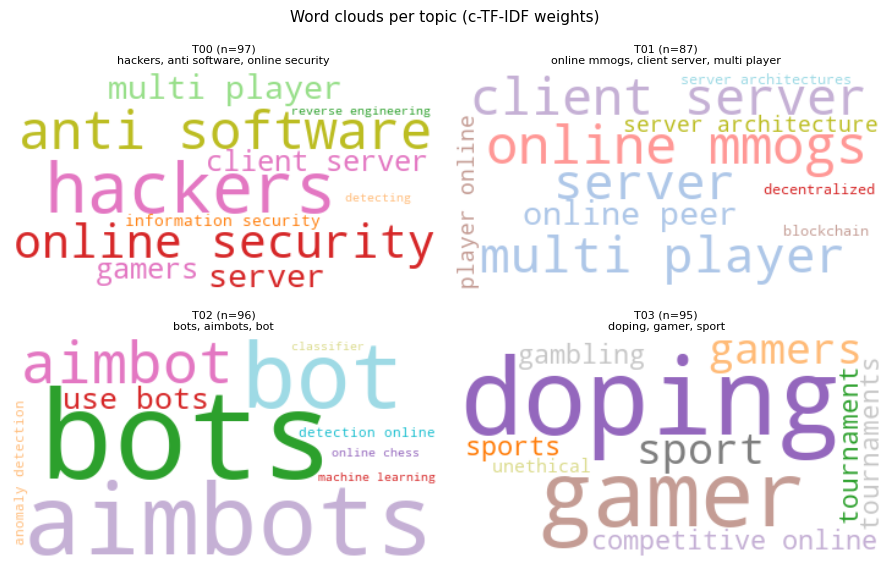

In [56]:
# Fig B.5 — Word clouds per topic
all_topics_dict = topic_model.get_topics()
wc_ids   = valid_topics[:min(16, len(valid_topics))]
ncols_wc = 2
nrows_wc = (len(wc_ids) + ncols_wc - 1) // ncols_wc

fig_wc, axes_wc = plt.subplots(nrows_wc, ncols_wc,
                                figsize=(4.5 * ncols_wc, 3.0 * nrows_wc))
axes_wc = np.array(axes_wc).flatten()

for ax, t_id in zip(axes_wc, wc_ids):
    old_id    = _topic_remap_rev[t_id]
    freq_dict = {
        w: max(float(s), 0.001)
        for w, s in all_topics_dict.get(old_id, [])
        if w not in GENERIC_KEYWORD_STOPLIST and float(s) > 0
    }
    n_docs = int((np.array(new_topics) == t_id).sum())
    if freq_dict:
        wc = WordCloud(width=350, height=180, background_color="white",
                       max_words=25, colormap="tab20",
                       prefer_horizontal=0.9).generate_from_frequencies(freq_dict)
        ax.imshow(wc, interpolation="bilinear")
    else:
        ax.text(0.5, 0.5, "(no keywords)", ha="center", va="center", transform=ax.transAxes)
    top3 = ", ".join(w for w, _ in topic_model.get_topic(old_id)[:3])
    ax.set_title(f"T{t_id:02d} (n={n_docs})\n{top3}", fontsize=8)
    ax.axis("off")

for ax in axes_wc[len(wc_ids):]:
    ax.axis("off")

plt.suptitle("Word clouds per topic (c-TF-IDF weights)", fontsize=11)
plt.tight_layout()
plt.savefig(OUT / "05_B5_wordclouds.png", dpi=150, bbox_inches="tight")
plt.savefig(OUT / "05_B5_wordclouds.svg", bbox_inches="tight")
plt.show()


In [49]:
# Fig B.6 — Topic × Contribution Type heatmap (row-normalised %)
df_v = df[df["topic_id_clean"] >= 0].copy()
df_v["t_short"] = df_v["topic_id_clean"].map(lambda t: f"T{t:02d}")

ct_count = pd.crosstab(df_v["t_short"], df_v["contribution_type"])
ct_count = ct_count.reindex(sorted(ct_count.index))
ct_pct   = ct_count.div(ct_count.sum(axis=1), axis=0).mul(100).round(1)

nmi_ct = normalized_mutual_info_score(
    df_v["topic_id_clean"].astype(str),
    df_v["contribution_type"].fillna("unknown"),
)

fig_ct = go.Figure(go.Heatmap(
    z=ct_pct.values,
    x=ct_pct.columns.tolist(),
    y=ct_pct.index.tolist(),
    colorscale="Blues", zmin=0, zmax=100,
    hovertemplate="%{y}  ×  %{x}<br>%{z:.1f}%  (N=%{customdata})<extra></extra>",
    customdata=ct_count.values,
    colorbar=dict(title="Row %", len=0.8),
))
fig_ct.update_layout(
    title=f"Fig B.6 — Topic × Contribution Type (row %, NMI={nmi_ct:.3f})",
    xaxis=dict(tickangle=-25, tickfont=dict(size=11)),
    yaxis=dict(tickfont=dict(size=11)),
    height=max(300, len(ct_pct) * 44 + 140),
    margin=dict(l=80, b=130, t=70, r=100),
)
fig_ct.show()
save_figure(fig_ct, "05_B6_topic_contribution_type")
print(f"NMI (topic vs Contribution Type): {nmi_ct:.3f}")

NMI (topic vs Contribution Type): 0.334


In [50]:
# Fig B.7 — Topic × Study Approach heatmap (row-normalised %)
sa_count = pd.crosstab(df_v["t_short"], df_v["study_approach"])
sa_count = sa_count.reindex(sorted(sa_count.index))
sa_pct   = sa_count.div(sa_count.sum(axis=1), axis=0).mul(100).round(1)

nmi_sa = normalized_mutual_info_score(
    df_v["topic_id_clean"].astype(str),
    df_v["study_approach"].fillna("unknown"),
)

fig_sa = go.Figure(go.Heatmap(
    z=sa_pct.values,
    x=sa_pct.columns.tolist(),
    y=sa_pct.index.tolist(),
    colorscale="Oranges", zmin=0, zmax=100,
    hovertemplate="%{y}  ×  %{x}<br>%{z:.1f}%  (N=%{customdata})<extra></extra>",
    customdata=sa_count.values,
    colorbar=dict(title="Row %", len=0.8),
))
fig_sa.update_layout(
    title=f"Fig B.7 — Topic × Study Approach (row %, NMI={nmi_sa:.3f})",
    xaxis=dict(tickangle=-25, tickfont=dict(size=11)),
    yaxis=dict(tickfont=dict(size=11)),
    height=max(300, len(sa_pct) * 44 + 140),
    margin=dict(l=80, b=130, t=70, r=100),
)
fig_sa.show()
save_figure(fig_sa, "05_B7_topic_study_approach")
print(f"NMI (topic vs Study Approach): {nmi_sa:.3f}")

NMI (topic vs Study Approach): 0.333


In [51]:
# Fig B.8 — Topic distribution by research phase (count / % toggle)
phase_order = ["Phase 1 (2000–12)", "Phase 2 (2012–19)", "Phase 3 (2019–26)"]

phase_topic = (
    df_v.groupby(["phase", "topic_id_clean"]).size()
    .unstack(fill_value=0)
    .reindex(phase_order)
)
phase_totals  = phase_topic.sum(axis=1)
phase_pct     = phase_topic.div(phase_totals, axis=0).mul(100).round(1)
t_ids_phase   = phase_topic.columns.tolist()

traces_cnt, traces_pct = [], []
for t_id in t_ids_phase:
    color  = CLUSTER_PALETTE[t_id % len(CLUSTER_PALETTE)]
    name   = topic_labels_map.get(t_id, f"T{t_id:02d}")
    x_lbls = [f"{p}<br>(N={int(phase_totals.get(p,0))})" for p in phase_order]
    cnt_v  = phase_topic[t_id].tolist()
    pct_v  = phase_pct[t_id].tolist()
    traces_cnt.append(go.Bar(
        name=name, x=x_lbls, y=cnt_v, marker_color=color, visible=True,
        text=[str(v) if v > 0 else "" for v in cnt_v],
        textposition="inside", textfont=dict(size=9, color="white"),
    ))
    traces_pct.append(go.Bar(
        name=name, x=x_lbls, y=pct_v, marker_color=color, visible=False,
        text=[f"{v:.0f}%" if v > 0 else "" for v in pct_v],
        textposition="inside", textfont=dict(size=9, color="white"),
    ))

n_t = len(t_ids_phase)
fig_phase = go.Figure(traces_cnt + traces_pct)
fig_phase.update_layout(
    barmode="stack",
    title="Fig B.8 — Topic distribution by research phase",
    xaxis_title="Phase", yaxis_title="Papers",
    legend_title="Topic",
    height=480,
    updatemenus=[dict(
        type="buttons", direction="right", x=0.0, y=1.12, xanchor="left",
        buttons=[
            dict(label="Count",   method="update",
                 args=[{"visible": [True]*n_t  + [False]*n_t}, {"yaxis.title.text": "Papers"}]),
            dict(label="Percent", method="update",
                 args=[{"visible": [False]*n_t + [True]*n_t},  {"yaxis.title.text": "% of phase"}]),
        ],
    )],
)
fig_phase.show()
save_figure(fig_phase, "05_B8_topic_by_phase")

In [ ]:
# Fig B.9 — Temporal topic network (pyvis)
# Layout: x = year (fixed), y = topic lane + jitter; no edges (purely positional)

CUSTOM_TOPIC_LABELS = {
    0: "Cheating Taxonomies and Security Foundations",
    1: "Networked Architectures and Cheat-Resistant Infrastructure",
    2: "Automation and ML-Based Cheat Detection",
    3: "Competitive Integrity, Player Norms, and Governance",
}

net_df  = df[df["topic_id_clean"] >= 0].copy().reset_index(drop=True)
min_yr  = int(net_df["Year"].min())
max_yr  = int(net_df["Year"].max())
yr_rng  = max(max_yr - min_yr, 1)

topics_net = sorted(net_df["topic_id_clean"].unique())
lane_of    = {t: i for i, t in enumerate(topics_net)}

X_SCALE = 2200
Y_SCALE = 200
JITTER  = 55
rng     = np.random.default_rng(42)

net = PNetwork(height="720px", width="100%", bgcolor="#ffffff", font_color="black")
net.toggle_physics(False)

# Year axis ticks
for yr in range(min_yr, max_yr + 1, 2):
    xp = int((yr - min_yr) / yr_rng * X_SCALE)
    net.add_node(f"yr_{yr}", label=str(yr), x=xp, y=-90, size=3,
                 color="#555555", shape="text",
                 font={"size": 14, "color": "#666666"}, physics=False)

# Topic lane labels — custom names, larger font
for t_id in topics_net:
    old_id   = _topic_remap_rev[t_id]
    fallback = ", ".join(w for w, _ in topic_model.get_topic(old_id)[:3])
    label    = f"{CUSTOM_TOPIC_LABELS.get(t_id, fallback)} (T{t_id:02d})"
    net.add_node(f"topic_{t_id}", label=label,
                 x=-480, y=lane_of[t_id] * Y_SCALE,
                 size=4, color="#333333", shape="text",
                 font={"size": 16, "color": "#222222", "bold": True}, physics=False)

# Paper nodes: color = topic, size ∝ √citations, hover = title/year/type
node_positions = {}
for _, row in net_df.iterrows():
    yr    = float(row["Year"])
    t_id  = int(row["topic_id_clean"])
    xp    = int((yr - min_yr) / yr_rng * X_SCALE)
    yp    = lane_of[t_id] * Y_SCALE + int(rng.integers(-JITTER, JITTER + 1))
    color = CLUSTER_PALETTE[t_id % len(CLUSTER_PALETTE)]
    sz    = max(9, float(np.sqrt(float(row["Cited_by"]) + 1)) * 4.5)
    title = str(row["Title"])[:65] if pd.notna(row["Title"]) else ""
    hover = (
        f"<b>{title}</b><br>"
        f"Year: {int(yr)} | Topic: T{t_id:02d}<br>"
        f"Citations: {int(row['Cited_by'])} | {row['contribution_type']}"
    )
    node_positions[int(row["Record_ID"])] = (xp, yp, t_id, yr, sz)
    net.add_node(int(row["Record_ID"]), label="",
                 x=xp, y=yp, color=color, size=sz,
                 title=hover, physics=False)

out_net = str(OUT / "05_B9_temporal_network.html")
net.write_html(out_net)
print(f"Temporal network saved → {out_net}")

# ── Static PNG via matplotlib ─────────────────────────────────────────────────
fig_net, ax_net = plt.subplots(figsize=(22, 8))
ax_net.set_facecolor("#ffffff")
fig_net.patch.set_facecolor("#ffffff")

# Paper nodes
for pid, (xp, yp, t_id, yr, sz) in node_positions.items():
    color = CLUSTER_PALETTE[t_id % len(CLUSTER_PALETTE)]
    ax_net.scatter(xp, -yp, c=color, s=(sz * 2.2) ** 1.5,
                   alpha=0.82, edgecolors="white", linewidths=0.4, zorder=2)

# Year ticks
for yr in range(min_yr, max_yr + 1, 2):
    xp = int((yr - min_yr) / yr_rng * X_SCALE)
    ax_net.axvline(xp, color="#dddddd", linewidth=0.6, zorder=0)
    ax_net.text(xp, 110, str(yr), ha="center", va="bottom",
                fontsize=11, color="#555555")

# Topic lane labels
for t_id in topics_net:
    yp_lane  = -(lane_of[t_id] * Y_SCALE)
    old_id   = _topic_remap_rev[t_id]
    fallback = ", ".join(w for w, _ in topic_model.get_topic(old_id)[:3])
    lbl      = f"{CUSTOM_TOPIC_LABELS.get(t_id, fallback)} (T{t_id:02d})"
    color    = CLUSTER_PALETTE[t_id % len(CLUSTER_PALETTE)]
    ax_net.text(-60, yp_lane, lbl, ha="right", va="center",
                fontsize=13, fontweight="bold", color=color)
    ax_net.axhline(yp_lane, color="#eeeeee", linewidth=0.8, zorder=0)

ax_net.set_xlim(-500, X_SCALE + 80)
ax_net.set_ylim(-(len(topics_net) * Y_SCALE - 80), 140)
ax_net.axis("off")
ax_net.set_title("Temporal Topic Network — Papers by Year and Topic",
                 fontsize=16, fontweight="bold", pad=14)

plt.tight_layout()
png_path = OUT / "05_B9_temporal_network.png"
svg_path = OUT / "05_B9_temporal_network.svg"
plt.savefig(png_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.savefig(svg_path, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Static PNG saved → {png_path}")

print(f"\nNodes: {len(net_df)} papers | Topics: {len(topics_net)}")
print("\nTopic legend:")
for t_id in topics_net:
    n_t    = int((net_df["topic_id_clean"] == t_id).sum())
    old_id = _topic_remap_rev[t_id]
    print(f"  T{t_id:02d} ({n_t:3d} papers, oldest={_min_yr_per[old_id]}) "
          f"[{CLUSTER_PALETTE[t_id % len(CLUSTER_PALETTE)]}]: "
          f"{CUSTOM_TOPIC_LABELS.get(t_id, '')}")

IFrame(out_net, width="100%", height=740)


In [53]:
# Fig B.10 — Citation distribution by topic (box plot, log y)
fig_cit = go.Figure()
for t_id in sorted(df_v["topic_id_clean"].unique()):
    sub   = df_v[df_v["topic_id_clean"] == t_id]
    color = CLUSTER_PALETTE[t_id % len(CLUSTER_PALETTE)]
    name  = topic_labels_map.get(t_id, f"T{t_id:02d}")
    fig_cit.add_trace(go.Box(
        y=sub["Cited_by"], name=f"T{t_id:02d}<br>(n={len(sub)})",
        marker_color=color, boxpoints="outliers",
        hovertemplate="%{y} citations<extra>" + name + "</extra>",
    ))

fig_cit.update_layout(
    title="Fig B.10 — Citation distribution by topic (log y-scale)",
    yaxis=dict(title="Citations", type="log"),
    xaxis_title="Topic",
    showlegend=False,
    height=430,
)
fig_cit.show()
save_figure(fig_cit, "05_B10_citation_by_topic")

In [54]:
# Export
out_df = df[["Record_ID", "topic_id", "topic_id_clean"]].copy()
if probs is not None and hasattr(probs, "ndim"):
    out_df["topic_prob"] = probs.astype(float) if probs.ndim == 1 else probs.max(axis=1).astype(float)
else:
    out_df["topic_prob"] = float("nan")

out_df.to_parquet(PROCESSED_DIR + "topic_assignments.parquet", index=False)
topic_model.get_topic_info().to_csv(str(OUT / "05_topic_info.csv"), index=False)

print(f"Winning config : {best_cfg} — {cfg['space']} | {cfg['algo']} | sil={cfg['silhouette']:.3f}")
print(f"Topics         : {len(valid_topics)}")
print(f"Outliers       : {int((np.array(new_topics)==-1).sum())}")
print("\nOutputs saved:")
for name in [
    "05_A1_ablation_table", "05_A2_ablation_umap_grid",
    "05_B1_topic_keywords", "05_B2_umap_scatter",
    "05_B3_centroid_distance", "05_B4_intertopic_map",
    "05_B5_wordclouds", "05_B6_topic_contribution_type",
    "05_B7_topic_study_approach", "05_B8_topic_by_phase",
    "05_B9_temporal_network", "05_B10_citation_by_topic",
]:
    print(f"  outputs/{name}.*")

Winning config : C — UMAP-5D | K-Means (K=4) | sil=0.585
Topics         : 4
Outliers       : 0

Outputs saved:
  outputs/05_A1_ablation_table.*
  outputs/05_A2_ablation_umap_grid.*
  outputs/05_B1_topic_keywords.*
  outputs/05_B2_umap_scatter.*
  outputs/05_B3_centroid_distance.*
  outputs/05_B4_intertopic_map.*
  outputs/05_B5_wordclouds.*
  outputs/05_B6_topic_contribution_type.*
  outputs/05_B7_topic_study_approach.*
  outputs/05_B8_topic_by_phase.*
  outputs/05_B9_temporal_network.*
  outputs/05_B10_citation_by_topic.*
